# Probability Distributions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammadtalhaishtiaq/ai-orchestrator/blob/main/00-foundations/statistics/04_distributions.ipynb)

**Time**: ~20 minutes

## What You'll Learn
- Normal distribution
- Binomial distribution
- Poisson distribution
- Exponential distribution
- When to use each

## Why Distributions?

Real-world data follows patterns. Understanding these patterns helps us:
- Model real phenomena
- Make predictions
- Calculate probabilities
- Design experiments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print("Probability Distributions: Modeling real-world data")

Probability Distributions: Modeling real-world data


---
## 1. Normal Distribution (Gaussian)

In [2]:
print("Normal Distribution:")
print("  - Bell-shaped curve")
print("  - Symmetric around mean (μ)")
print("  - Spread controlled by standard deviation (σ)")
print("  - Most values near mean, rare extremes")
print()
print("Rule of thumb:")
print("  - 68% of data within 1σ of mean")
print("  - 95% of data within 2σ of mean")
print("  - 99.7% of data within 3σ of mean")
print()
print("Real examples:")
print("  - Heights of people")
print("  - Test scores")
print("  - Measurement errors")

Normal Distribution:
  - Bell-shaped curve
  - Symmetric around mean (μ)
  - Spread controlled by standard deviation (σ)
  - Most values near mean, rare extremes

Rule of thumb:
  - 68% of data within 1σ of mean
  - 95% of data within 2σ of mean
  - 99.7% of data within 3σ of mean

Real examples:
  - Heights of people
  - Test scores
  - Measurement errors


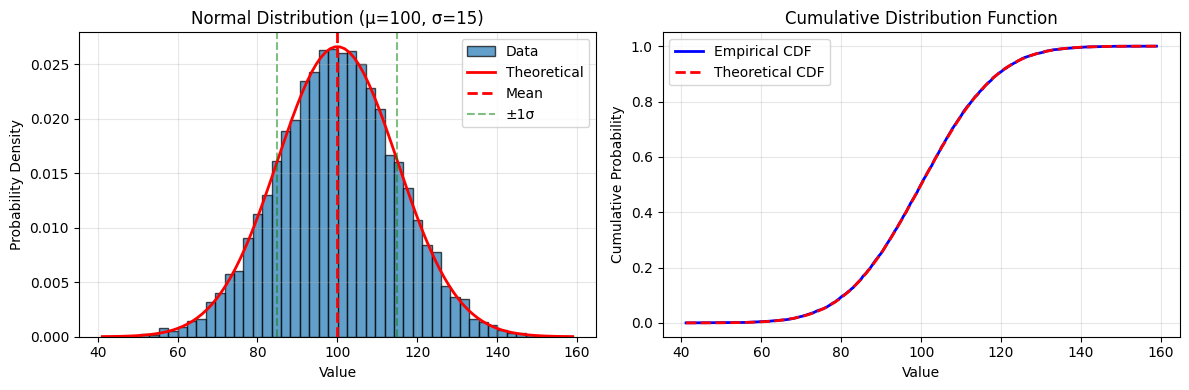


Data Statistics:
  Mean: 99.97
  Std Dev: 15.05
  Skewness: 0.0020 (should be ≈0)


In [3]:
# Generate normal distribution
mu, sigma = 100, 15  # Mean and std dev
normal_data = np.random.normal(mu, sigma, 10000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram with density
axes[0].hist(normal_data, bins=50, density=True, edgecolor='black', alpha=0.7, label='Data')
x = np.linspace(normal_data.min(), normal_data.max(), 100)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Theoretical')
axes[0].axvline(mu, color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(mu + sigma, color='green', linestyle='--', alpha=0.5, label='±1σ')
axes[0].axvline(mu - sigma, color='green', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Normal Distribution (μ=100, σ=15)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative distribution
sorted_data = np.sort(normal_data)
cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
axes[1].plot(sorted_data, cdf, 'b-', linewidth=2, label='Empirical CDF')
x = np.linspace(sorted_data.min(), sorted_data.max(), 100)
axes[1].plot(x, stats.norm.cdf(x, mu, sigma), 'r--', linewidth=2, label='Theoretical CDF')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('Cumulative Distribution Function')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nData Statistics:")
print(f"  Mean: {np.mean(normal_data):.2f}")
print(f"  Std Dev: {np.std(normal_data):.2f}")
print(f"  Skewness: {stats.skew(normal_data):.4f} (should be ≈0)")

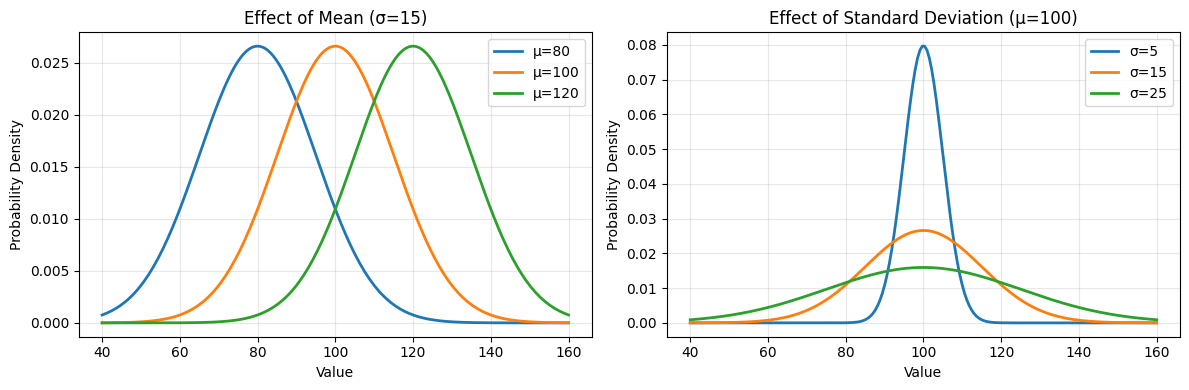

In [4]:
# Effect of parameters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(40, 160, 200)

# Different means
for mu in [80, 100, 120]:
    y = stats.norm.pdf(x, mu, 15)
    axes[0].plot(x, y, linewidth=2, label=f'μ={mu}')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Probability Density')
axes[0].set_title('Effect of Mean (σ=15)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Different standard deviations
for sigma in [5, 15, 25]:
    y = stats.norm.pdf(x, 100, sigma)
    axes[1].plot(x, y, linewidth=2, label=f'σ={sigma}')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('Effect of Standard Deviation (μ=100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 2. Binomial Distribution

In [5]:
print("Binomial Distribution:")
print("  - Number of successes in n trials")
print("  - Each trial has probability p of success")
print("  - Trials are independent")
print()
print("Parameters:")
print("  - n: number of trials")
print("  - p: probability of success in each trial")
print()
print("Real examples:")
print("  - Coin flips (n=10, p=0.5)")
print("  - Product defects (n=100, p=0.01)")
print("  - Email opens (n=1000, p=0.3)")
print("  - Disease presence tests (n=1, p=0.05)")

Binomial Distribution:
  - Number of successes in n trials
  - Each trial has probability p of success
  - Trials are independent

Parameters:
  - n: number of trials
  - p: probability of success in each trial

Real examples:
  - Coin flips (n=10, p=0.5)
  - Product defects (n=100, p=0.01)
  - Email opens (n=1000, p=0.3)
  - Disease presence tests (n=1, p=0.05)


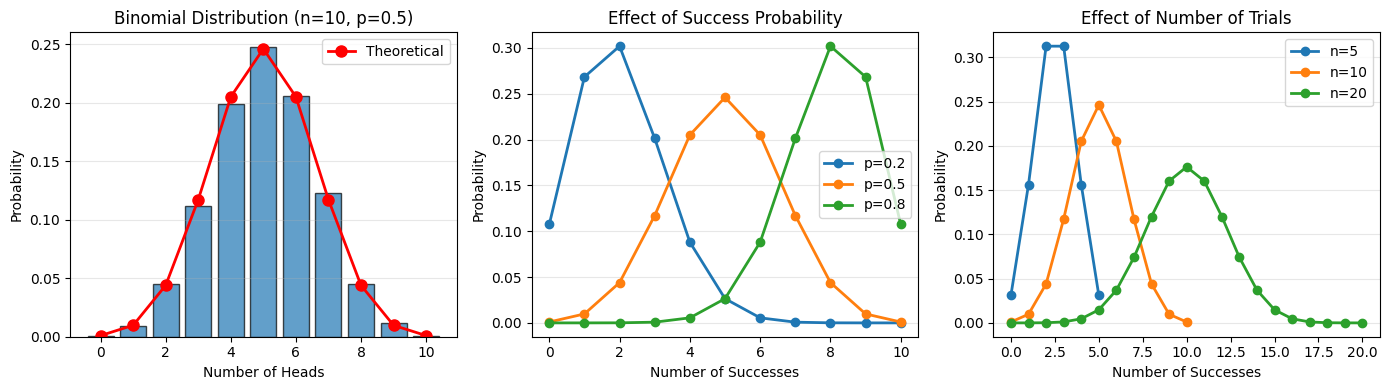


Binomial with n=10, p=0.5:
  Mean: 5.04 (theoretical: 5.0)
  Std: 1.59 (theoretical: 1.58)


In [6]:
# Coin flip example
n, p = 10, 0.5  # 10 flips, P(heads) = 0.5
binomial_data = np.random.binomial(n, p, 10000)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution
unique, counts = np.unique(binomial_data, return_counts=True)
axes[0].bar(unique, counts/len(binomial_data), alpha=0.7, edgecolor='black')
x = np.arange(0, n+1)
y = stats.binom.pmf(x, n, p)
axes[0].plot(x, y, 'ro-', linewidth=2, markersize=8, label='Theoretical')
axes[0].set_xlabel('Number of Heads')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Binomial Distribution (n={n}, p={p})')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Effect of p
for p_val in [0.2, 0.5, 0.8]:
    y = stats.binom.pmf(np.arange(0, n+1), n, p_val)
    axes[1].plot(np.arange(0, n+1), y, 'o-', linewidth=2, label=f'p={p_val}')
axes[1].set_xlabel('Number of Successes')
axes[1].set_ylabel('Probability')
axes[1].set_title('Effect of Success Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# Effect of n
for n_val in [5, 10, 20]:
    y = stats.binom.pmf(np.arange(0, n_val+1), n_val, 0.5)
    axes[2].plot(np.arange(0, n_val+1), y, 'o-', linewidth=2, label=f'n={n_val}')
axes[2].set_xlabel('Number of Successes')
axes[2].set_ylabel('Probability')
axes[2].set_title('Effect of Number of Trials')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nBinomial with n={n}, p={p}:")
print(f"  Mean: {np.mean(binomial_data):.2f} (theoretical: {n*p})")
print(f"  Std: {np.std(binomial_data):.2f} (theoretical: {np.sqrt(n*p*(1-p)):.2f})")

---
## 3. Poisson Distribution

In [7]:
print("Poisson Distribution:")
print("  - Counts of events in fixed interval")
print("  - Events occur independently at constant rate")
print("  - Parameter: λ (lambda) = expected count")
print()
print("Real examples:")
print("  - Website visitors per hour")
print("  - Emails per day")
print("  - Calls to helpdesk per minute")
print("  - Radioactive decay events")
print()
print("Note: Use when n is large, p is small, np is moderate")

Poisson Distribution:
  - Counts of events in fixed interval
  - Events occur independently at constant rate
  - Parameter: λ (lambda) = expected count

Real examples:
  - Website visitors per hour
  - Emails per day
  - Calls to helpdesk per minute
  - Radioactive decay events

Note: Use when n is large, p is small, np is moderate


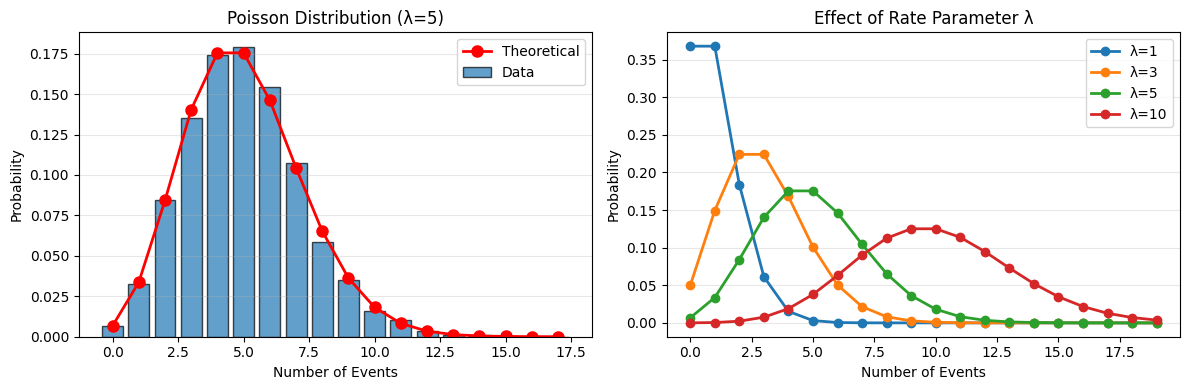


Poisson with λ=5:
  Mean: 5.01 (theoretical: 5)
  Std: 2.22 (theoretical: 2.24)

Key property: Mean = Variance = λ


In [8]:
# Poisson example: visitors per hour
lam = 5  # On average 5 visitors per hour
poisson_data = np.random.poisson(lam, 10000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
unique, counts = np.unique(poisson_data, return_counts=True)
axes[0].bar(unique, counts/len(poisson_data), alpha=0.7, edgecolor='black', label='Data')
x = np.arange(0, max(unique)+1)
y = stats.poisson.pmf(x, lam)
axes[0].plot(x, y, 'ro-', linewidth=2, markersize=8, label='Theoretical')
axes[0].set_xlabel('Number of Events')
axes[0].set_ylabel('Probability')
axes[0].set_title(f'Poisson Distribution (λ={lam})')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Effect of λ
for lam_val in [1, 3, 5, 10]:
    x = np.arange(0, 20)
    y = stats.poisson.pmf(x, lam_val)
    axes[1].plot(x, y, 'o-', linewidth=2, label=f'λ={lam_val}')
axes[1].set_xlabel('Number of Events')
axes[1].set_ylabel('Probability')
axes[1].set_title('Effect of Rate Parameter λ')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nPoisson with λ={lam}:")
print(f"  Mean: {np.mean(poisson_data):.2f} (theoretical: {lam})")
print(f"  Std: {np.std(poisson_data):.2f} (theoretical: {np.sqrt(lam):.2f})")
print(f"\nKey property: Mean = Variance = λ")

---
## 4. Exponential Distribution

In [9]:
print("Exponential Distribution:")
print("  - Time between events (in Poisson process)")
print("  - Memoryless: P(X > t+s | X > t) = P(X > s)")
print("  - Decays rapidly, long tail")
print()
print("Real examples:")
print("  - Time until next customer arrives")
print("  - Lifespan of device before failure")
print("  - Time between radioactive decays")
print()
print("Parameter: λ (rate) or β=1/λ (scale/mean)")

Exponential Distribution:
  - Time between events (in Poisson process)
  - Memoryless: P(X > t+s | X > t) = P(X > s)
  - Decays rapidly, long tail

Real examples:
  - Time until next customer arrives
  - Lifespan of device before failure
  - Time between radioactive decays

Parameter: λ (rate) or β=1/λ (scale/mean)


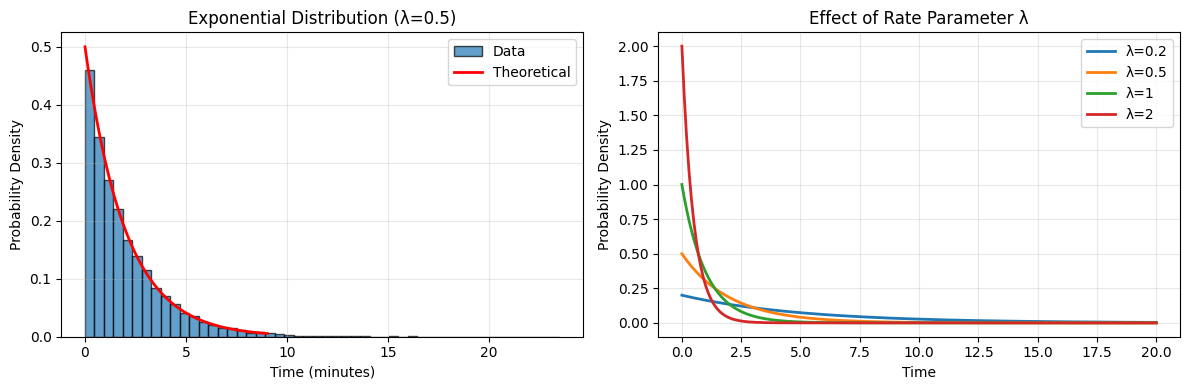


Exponential with λ=0.5:
  Mean: 2.00 (theoretical: 2.0)
  Std: 2.00 (theoretical: 2.00)

Key insight: Right-skewed, long tail


In [10]:
# Exponential example: time between customer arrivals
lam = 0.5  # 0.5 arrivals per minute (mean 2 minutes)
exponential_data = np.random.exponential(1/lam, 10000)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution
axes[0].hist(exponential_data, bins=50, density=True, edgecolor='black', alpha=0.7, label='Data')
x = np.linspace(0, np.percentile(exponential_data, 99), 100)
y = stats.expon.pdf(x, scale=1/lam)
axes[0].plot(x, y, 'r-', linewidth=2, label='Theoretical')
axes[0].set_xlabel('Time (minutes)')
axes[0].set_ylabel('Probability Density')
axes[0].set_title(f'Exponential Distribution (λ={lam})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Effect of λ
x = np.linspace(0, 20, 200)
for lam_val in [0.2, 0.5, 1, 2]:
    y = stats.expon.pdf(x, scale=1/lam_val)
    axes[1].plot(x, y, linewidth=2, label=f'λ={lam_val}')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Probability Density')
axes[1].set_title('Effect of Rate Parameter λ')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExponential with λ={lam}:")
print(f"  Mean: {np.mean(exponential_data):.2f} (theoretical: {1/lam})")
print(f"  Std: {np.std(exponential_data):.2f} (theoretical: {1/lam:.2f})")
print(f"\nKey insight: Right-skewed, long tail")

---
## 5. Distribution Comparison

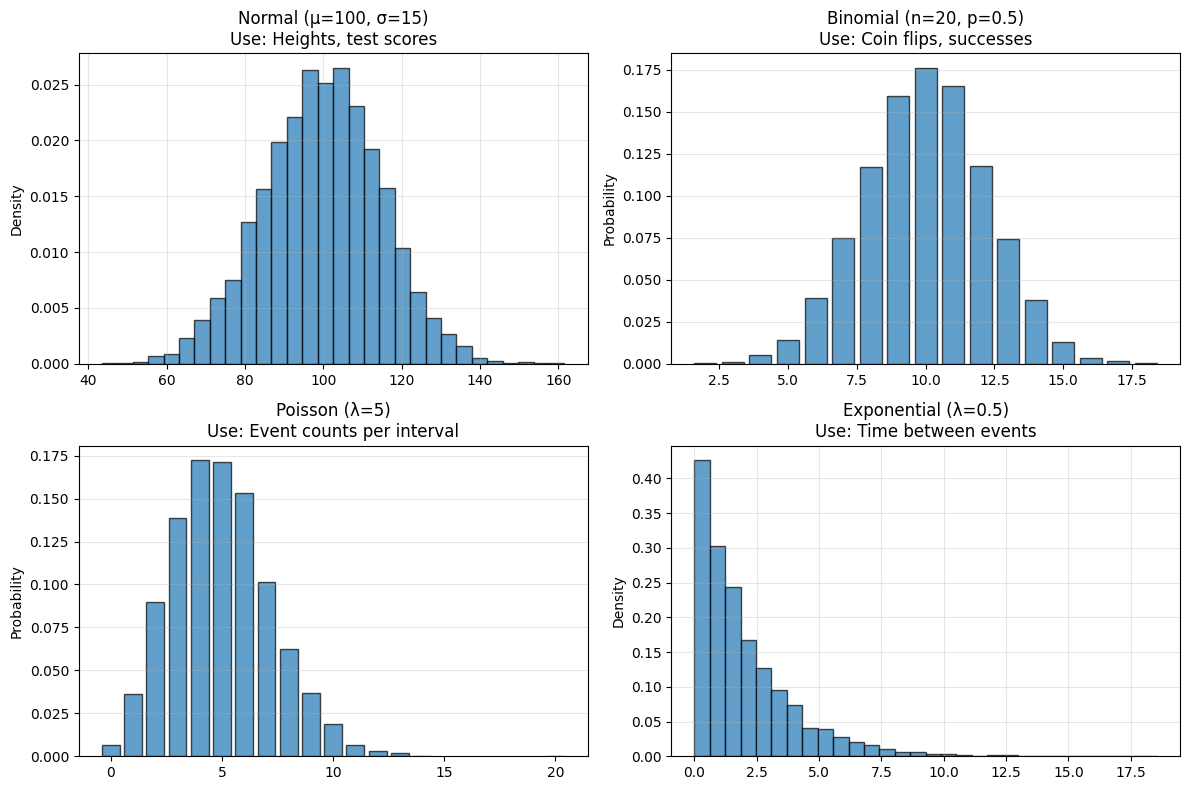

In [11]:
# Compare all distributions side-by-side
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Normal
normal = np.random.normal(100, 15, 5000)
axes[0, 0].hist(normal, bins=30, density=True, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Normal (μ=100, σ=15)\nUse: Heights, test scores')
axes[0, 0].set_ylabel('Density')
axes[0, 0].grid(True, alpha=0.3)

# Binomial
binomial = np.random.binomial(20, 0.5, 5000)
unique, counts = np.unique(binomial, return_counts=True)
axes[0, 1].bar(unique, counts/len(binomial), alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Binomial (n=20, p=0.5)\nUse: Coin flips, successes')
axes[0, 1].set_ylabel('Probability')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Poisson
poisson = np.random.poisson(5, 5000)
unique, counts = np.unique(poisson, return_counts=True)
axes[1, 0].bar(unique, counts/len(poisson), alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Poisson (λ=5)\nUse: Event counts per interval')
axes[1, 0].set_ylabel('Probability')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Exponential
exponential = np.random.exponential(2, 5000)
axes[1, 1].hist(exponential, bins=30, density=True, edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Exponential (λ=0.5)\nUse: Time between events')
axes[1, 1].set_ylabel('Density')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Summary table
summary = pd.DataFrame({
    'Distribution': ['Normal', 'Binomial', 'Poisson', 'Exponential'],
    'Type': ['Continuous', 'Discrete', 'Discrete', 'Continuous'],
    'Use Case': ['Measurements', 'Success counts', 'Event counts', 'Wait times'],
    'Parameters': ['μ, σ', 'n, p', 'λ', 'λ'],
    'Mean': ['μ', 'np', 'λ', '1/λ'],
    'Variance': ['σ²', 'np(1-p)', 'λ', '1/λ²']
})

print(summary.to_string(index=False))

Distribution       Type       Use Case Parameters Mean Variance
      Normal Continuous   Measurements       μ, σ    μ       σ²
    Binomial   Discrete Success counts       n, p   np  np(1-p)
     Poisson   Discrete   Event counts          λ    λ        λ
 Exponential Continuous     Wait times          λ  1/λ     1/λ²


---
## Key Takeaways

1. **Normal**: Bell curve, 68-95-99.7 rule, symmetric
2. **Binomial**: Discrete, n independent trials, each with p probability
3. **Poisson**: Event counts in time intervals, λ = mean
4. **Exponential**: Continuous, time between events, memoryless
5. **Choose by**: What are you measuring?

---
## Your Turn

1. Generate 1000 samples from each distribution
2. Calculate mean and variance for each
3. Create Q-Q plots to check normality
4. Fit a distribution to real data

In [13]:
# Your code here